# **Comparing Images**

#### **Objectives:**
1. Compare Images using Mean Squared Error (MSE)
2. UCompare Images using Structual Similarity

> **Assets note.** The original asset pack for this course was never committed to this repo (no `images/`, `videos/`, or `haarcascades/`, in any past commit). This fork ships a real, working replacement set — sourced from OpenCV's own official sample data where a good match existed, generated procedurally where it didn't (see `scripts/generate_assets.py`) — under `assets/images/`, `assets/videos/`, and `assets/haarcascades/`, plus small, called-out fixes wherever a swap needed one. Nothing else was removed. See the README for the full source list. No download step needed — just run the cells top to bottom.

In [1]:
import cv2
import numpy as np
from matplotlib import pyplot as plt
from skimage.metrics import structural_similarity

# Define our imshow function 
def imshow(title = "Image", image = None, size = 8):
    w, h = image.shape[0], image.shape[1]
    aspect_ratio = w/h
    plt.figure(figsize=(size * aspect_ratio,size))
    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.title(title)
    plt.show()

#### **Mean Squared Error (MSE)**

The MSE between the two images is the sum of the squared difference between the two images. This can easily be implemented with numpy.

The lower the MSE the more similar the images are.

**Why MSE alone can be a bad judge of "similar":** it's a purely pixel-by-pixel arithmetic difference — squares every per-pixel gap and averages them — with no concept of *where* differences are or what visual pattern they form. A photo shifted by one pixel, or uniformly brightened, can score just as badly on MSE as one with genuinely different content, because MSE can't tell "the same image, moved/lit differently" apart from "a different image".

**Structural similarity (SSIM)**, computed below by `structural_similarity`, tries to match human judgment more closely by comparing three things in local windows across the image rather than isolated pixels: **luminance** (average brightness), **contrast** (spread of brightness), and **structure** (the correlation of brightness *patterns* once luminance/contrast are factored out — i.e., do the edges and textures line up, independent of exposure). Two images can differ in brightness yet still score high on the *structural* component if their patterns genuinely match — which is exactly the `fireworks1` vs. `fireworks1b` (brightness-boosted) comparison a few cells down: watch MSE jump while SSIM stays comparatively forgiving.

In [2]:
def mse(image1, image2):
	# Images must be of the same dimension
	error = np.sum((image1.astype("float") - image2.astype("float")) ** 2)
	error /= float(image1.shape[0] * image1.shape[1])

	return error

#### **Using 3 images**

1. Fireworks1
2. Fireworks1 with brightness enhanced
3. Fireworks2

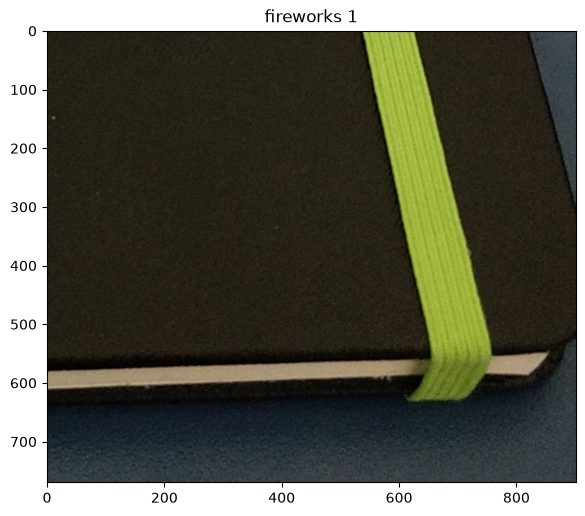

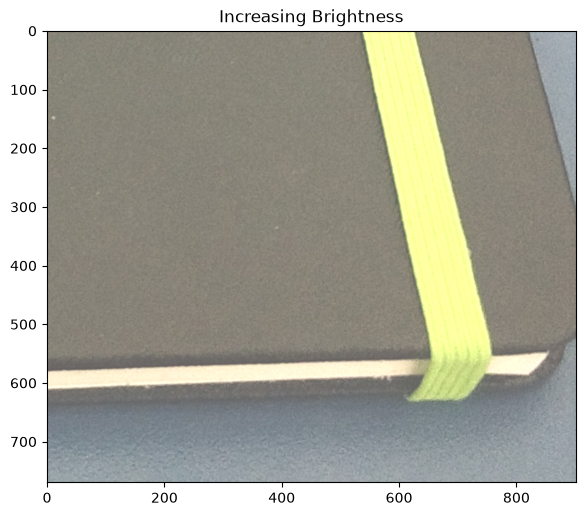

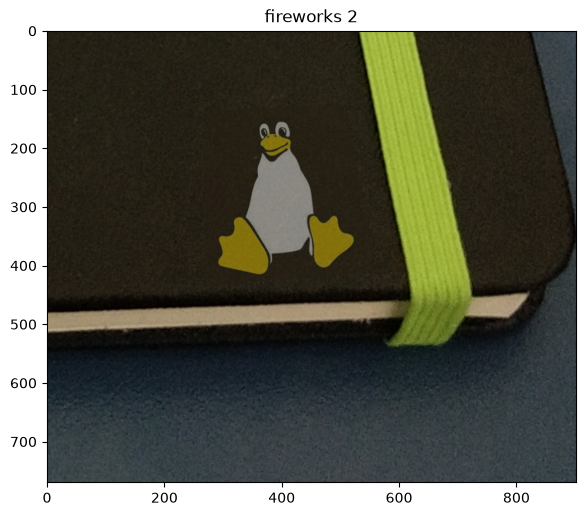

In [3]:
fireworks1 = cv2.imread('assets/images/fireworks.jpeg')
fireworks2 = cv2.imread('assets/images/fireworks2.jpeg')

M = np.ones(fireworks1.shape, dtype = "uint8") * 100 
fireworks1b = cv2.add(fireworks1, M)

imshow("fireworks 1", fireworks1)
imshow("Increasing Brightness", fireworks1b)
imshow("fireworks 2", fireworks2)

In [4]:
def compare(image1, image2):
  image1 = cv2.cvtColor(image1, cv2.COLOR_BGR2GRAY)
  image2 = cv2.cvtColor(image2, cv2.COLOR_BGR2GRAY)
  print('MSE = {:.2f}'.format(mse(image1, image2)))
  print('SS = {:.2f}'.format(structural_similarity(image1, image2)))

In [5]:
# When they're the same
compare(fireworks1, fireworks1)

MSE = 0.00
SS = 1.00


In [6]:
# When comparing similar but not same images

compare(fireworks1, fireworks2)

MSE = 1600.58
SS = 0.56


In [7]:
# When comparing same images but at different brightness scales 

compare(fireworks1, fireworks1b)

MSE = 9757.74
SS = 0.51


In [8]:
compare(fireworks2, fireworks1b)

MSE = 10205.23
SS = 0.36


### Small experiments worth running

- Visualize *where* two images differ, not just by how much: `diff = cv2.absdiff(img1, img2)` then threshold and overlay in red — much more actionable than a single MSE number.
- `structural_similarity` accepts `full=True` and returns a per-pixel similarity map — display it as a heatmap next to the two source images.